# 1.8 — Go nuts with your LLM 🚀 Builder · grupo

Este notebook es el pipeline reproducible del post de la semana 1: carga el snapshot, calcula todo lo que el post afirma, y exporta las figuras y los JSON que consume el sitio (`site/src/data/week1/`, `site/src/assets/week1/`).

**Pregunta:** ¿in-degree y out-degree miden lo mismo?

In [1]:
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
import sgi
sgi.set_style()

G, nodes = sgi.load_marvel(week=1)
U = G.to_undirected()
table = sgi.degree_table(G, nodes)
name = nx.get_node_attributes(G, "name")
print(f"n={G.number_of_nodes()}  m={G.number_of_edges()}  m_und={U.number_of_edges()}  <k>={2*U.number_of_edges()/303:.2f}")

n=303  m=1784  m_und=1434  <k>=9.47


## 1. Dos formas distintas

 in-degree: max=106  media=5.89  mediana=3  ceros=58
out-degree: max= 28  media=5.89  mediana=4  ceros=20

Spider-Man recibe 106 links = 35% de los demás personajes


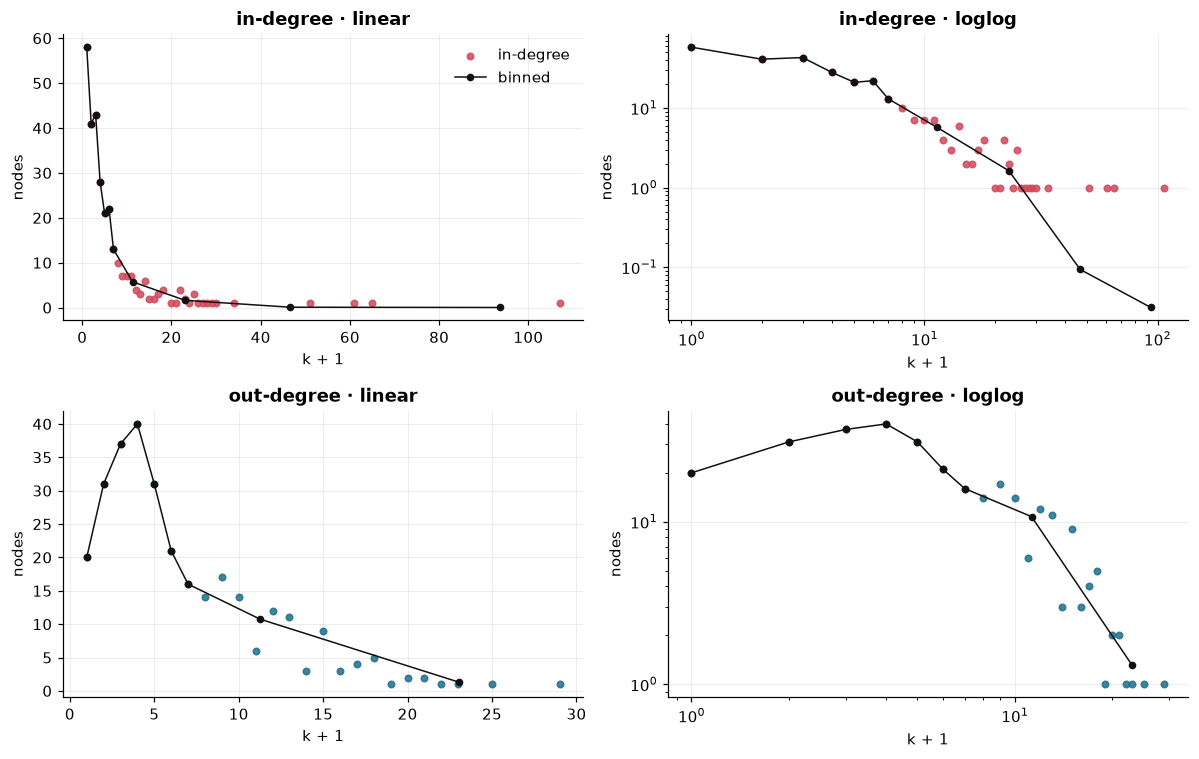

In [2]:
for kind in ("in", "out"):
    k = table[f"{kind}_degree"]
    print(f"{kind:>3}-degree: max={k.max():>3}  media={k.mean():.2f}  mediana={k.median():.0f}  ceros={int((k == 0).sum())}")
print(f"\nSpider-Man recibe {G.in_degree('Spider-Man')} links = {G.in_degree('Spider-Man')/302:.0%} de los demás personajes")
fig = sgi.degree_panels(table)
sgi.save_fig(fig, "degree-panels", week=1); plt.show()

## 2. Los famosos no devuelven el link

Reciprocidad global y de los hubs. Se calcula de dos formas independientes como verificación.

In [3]:
# vía 1: contar aristas cuya inversa existe
recip_edges = sum(1 for a, b in G.edges if G.has_edge(b, a))
# vía 2: aritmética m_dirigido - m_no_dirigido = pares mutuos
mutual_pairs = G.number_of_edges() - U.number_of_edges()
assert recip_edges == 2 * mutual_pairs
print(f"pares mutuos: {mutual_pairs}  →  reciprocidad = {recip_edges}/{G.number_of_edges()} = {recip_edges/G.number_of_edges():.1%}")

def reciprocidad(v):
    """De los que enlazan a v, ¿a cuántos enlaza v de vuelta?"""
    pred = list(G.predecessors(v))
    return sum(1 for u in pred if G.has_edge(v, u)), len(pred)

hubs = sgi.top(table, "in", 8)
hubs["back"], hubs["received"] = zip(*(reciprocidad(v) for v in hubs.node_id))
hubs["reciprocity"] = (hubs.back / hubs.received).map("{:.0%}".format)
hubs

pares mutuos: 350  →  reciprocidad = 700/1784 = 39.2%


,name,node_id,in_degree,back,received,reciprocity
0,Spider-Man,Spider-Man,106,9,106,8%
1,Hulk,Hulk,64,9,64,14%
2,Wolverine (character),Wolverine_(character),60,14,60,23%
3,Doctor Strange,Doctor_Strange,50,10,50,20%
4,Deadpool,Deadpool,33,11,33,33%
5,She-Hulk,She-Hulk,29,12,29,41%
6,Scarlet Witch,Scarlet_Witch,28,10,28,36%
7,Black Panther (character),Black_Panther_(character),27,7,27,26%


## 3. Los que hablan no son los famosos

In [4]:
top_in  = sgi.top(table, "in").merge(table[["node_id", "out_degree"]], on="node_id")
top_out = sgi.top(table, "out").merge(table[["node_id", "in_degree"]], on="node_id")
display(top_in[["name", "in_degree", "out_degree"]]); display(top_out[["name", "out_degree", "in_degree"]])

,name,in_degree,out_degree
0,Spider-Man,106,9
1,Hulk,64,10
2,Wolverine (character),60,17
3,Doctor Strange,50,17
4,Deadpool,33,19


,name,out_degree,in_degree
0,Betsy Braddock,28,7
1,Cloak and Dagger (characters),24,11
2,Adam Warlock,22,8
3,Venom (character),21,17
4,She-Hulk,20,29


## 4. Los 17 que no están en la historia

In [5]:
iso = [name[v] for v in G if G.degree(v) == 0]
print(len(iso), "aislados:"); print(*iso, sep="\n  ")
print("\nsolo desde la lista de aristas tendríamos", nx.DiGraph(list(G.edges)).number_of_nodes(), "nodos")

17 aislados:
Baymax
  Bird-Brain (Marvel Comics)
  Black Fox (Robert Paine)
  Brain Drain (character)
  Breeze Barton
  Captain Midlands
  Charcoal (comics)
  Father Time (Marvel Comics)
  Happy Sam Sawyer
  Hellfire (J. T. Slade)
  Illuminator (Marvel Comics)
  Miracleman (character)
  Ogre (Marvel Comics)
  Sean and Chris
  Solarman
  Super Rabbit
  Yo-Yo Rodriguez

solo desde la lista de aristas tendríamos 286 nodos


## 5. Exportar lo que consume el sitio

In [6]:
deg = table.set_index("node_id")
thumbs = sgi.fetch_thumbnails(nodes.node_id, week=1)   # API de Wikipedia, con caché
print(f"{len(thumbs)}/303 personajes con imagen")
network = {
    "meta": {"week": 1, "snapshot": "2026-08-26", "n": G.number_of_nodes(), "m": G.number_of_edges()},
    "nodes": [{"id": v, "name": deg.loc[v, "name"], "in": int(deg.loc[v, "in_degree"]),
               "out": int(deg.loc[v, "out_degree"]), "url": G.nodes[v]["url"],
               "desc": G.nodes[v]["description"], "thumb": thumbs.get(v)} for v in G.nodes],
    "links": [{"source": a, "target": b} for a, b in G.edges],
}
dist = {}
for kind in ("in", "out"):
    k = table[f"{kind}_degree"].to_numpy()
    dist[kind] = {"raw": sgi.raw_distribution(k).to_dict("records"),
                  "binned": sgi.goodies_bins(k).to_dict("records"),
                  "top": sgi.top(table, kind, 10).rename(columns={f"{kind}_degree": "k"}).to_dict("records")}
for obj, nm in [(network, "network"), (dist, "degree-distributions")]:
    print("✓", sgi.save_json(obj, nm, week=1).relative_to(sgi.ROOT))
print("✓", sgi.save_table(table, "degree-table", week=1).relative_to(sgi.ROOT))

254/303 personajes con imagen
✓ data/week1/exports/network.json
✓ data/week1/exports/degree-distributions.json
✓ data/week1/exports/degree-table.csv


---

Con esto, el post en `site/src/content/posts/week1.mdx` tiene todos sus números respaldados por este notebook. Si cambia el análisis: correr este notebook → commit → la Action publica.